In [1]:
import pandas as pd
import numpy as np

In [11]:
# Load the dataset`
# Assuming the dataset is in CSV format
housing_data = pd.read_csv('datasets/housing.csv')
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Display basic information about the dataset
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [13]:
housing_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [14]:
# describe the dataset
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


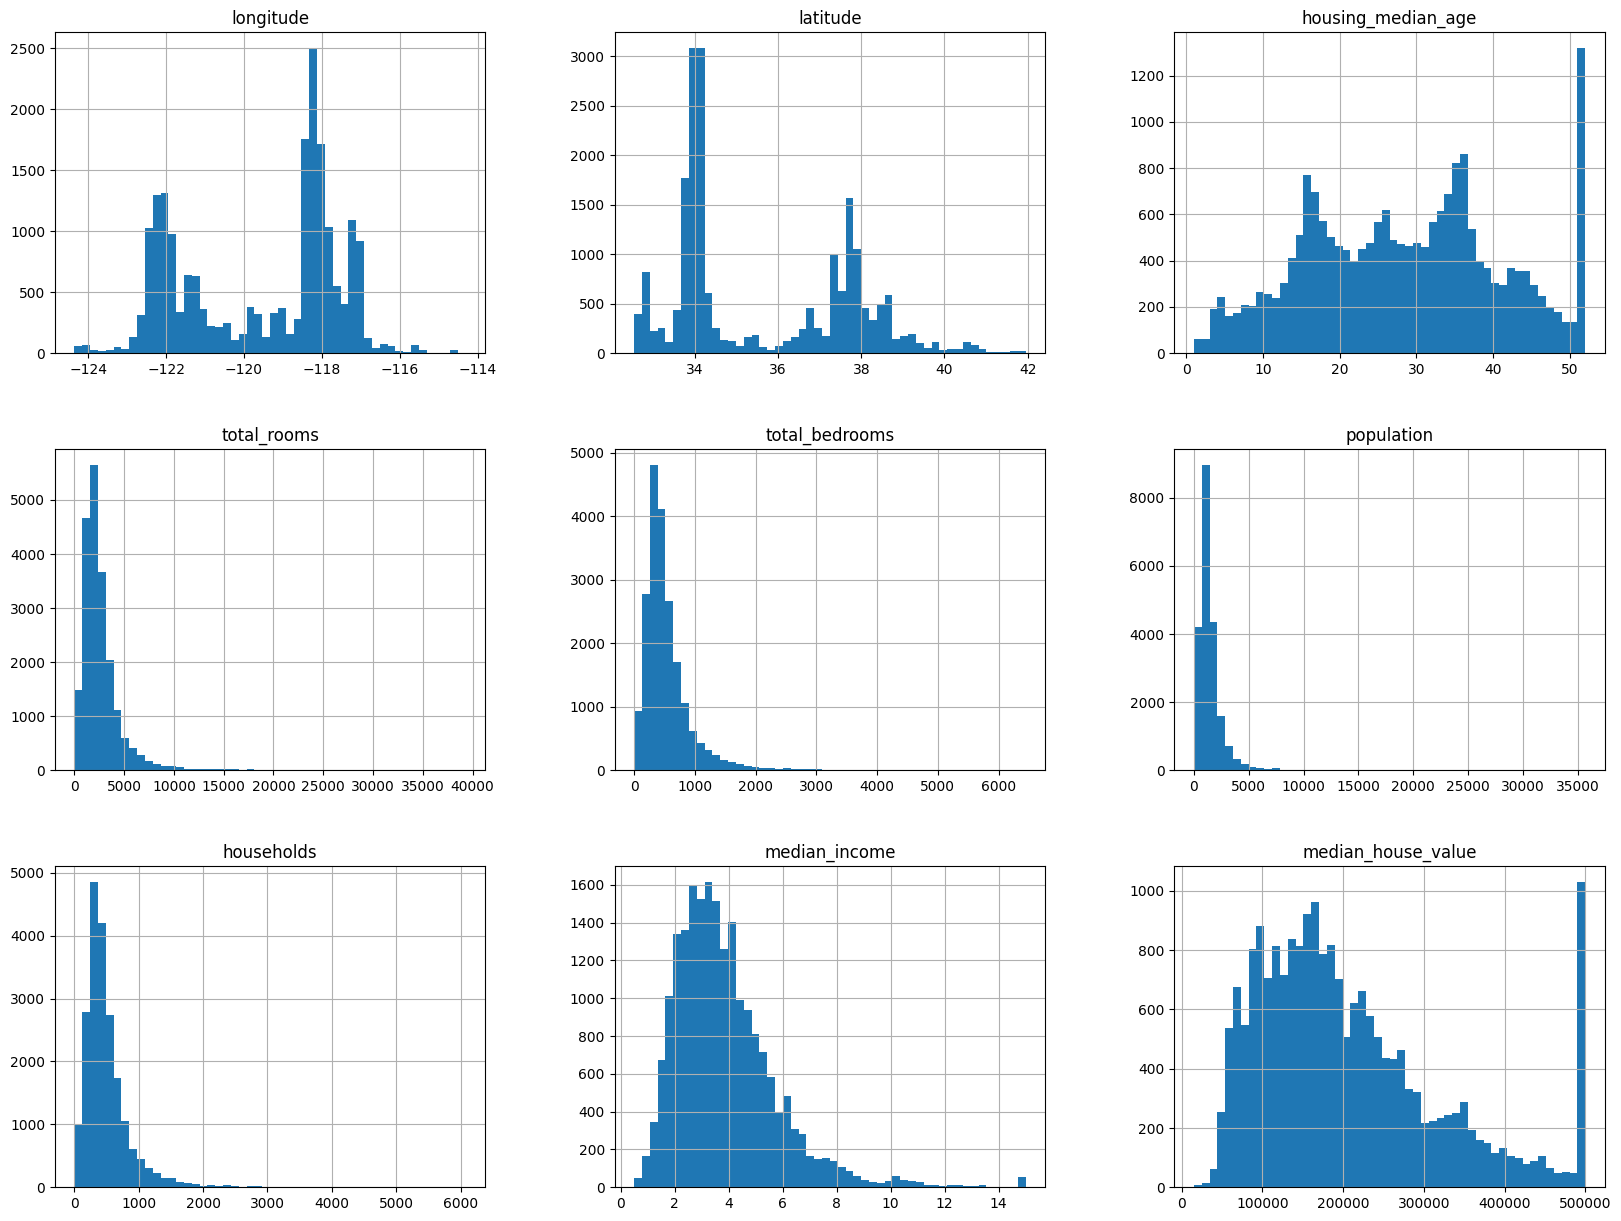

In [16]:
# Visualize the dataset
%matplotlib inline
import matplotlib.pyplot as plt
housing_data.hist(bins=50, figsize=(20,15))
plt.show()

Splitting a Dataset into Training and Testing Sets
This document outlines methods to split a dataset into training and testing sets, ensuring proper evaluation of machine learning models. The code examples demonstrate random sampling and identifier-based splitting to create consistent test sets.
Random Sampling (Basic but Problematic)
The following function splits a dataset randomly into training and testing sets based on a specified test ratio (e.g., 20% for testing). However, it shuffles the data differently each time it runs, which can lead to inconsistent test sets and potential data leakage over multiple runs.
import numpy as np

```
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
```
Issue: Running this function multiple times generates different test sets, which may allow the model to "see" the entire dataset over time, undermining the purpose of a separate test set.
Consistent Splitting Using Identifiers
To ensure a consistent test set across multiple runs, you can use a unique identifier for each instance. This method remains stable even if the dataset is updated, as long as the identifiers are consistent.
Function for Identifier-Based Splitting
This function uses a hash of an identifier to decide whether an instance belongs to the test set. It ensures that the same instances are selected for the test set every time, based on a test ratio.
import hashlib
import numpy as np

```
def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]
```
Using Row Index as Identifier
If the dataset lacks a unique identifier, you can use the row index as a temporary ID. This assumes new data is appended to the end of the dataset and no rows are deleted.
```
# Use row index as ID
housing_with_id = housing_data.reset_index()  # Adds an 'index' column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")
```

Using Stable Features as Identifier
For more robust splitting, you can create an identifier from stable features, such as latitude and longitude in a housing dataset. This ensures consistency even if rows are reordered or deleted.
```
# Create a unique ID from latitude and longitude
housing_with_id["id"] = housing_data["longitude"] * 1000 + housing_data["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")
```
Note: When using latitude and longitude, ensure the combination creates unique IDs. In some cases, coarse location data may lead to duplicate IDs, introducing sampling bias.
Key Considerations

Random Sampling: Simple but problematic due to inconsistent splits across runs.
Identifier-Based Splitting: Ensures consistent test sets, even with dataset updates, by using stable identifiers like row indices or derived features.
Best Practice: Use identifier-based splitting or Scikit-Learn’s train_test_split with a fixed random_state for reproducibility. For critical features, consider stratified sampling (e.g., using StratifiedShuffleSplit) to maintain representative distributions.


In [20]:
# using skelarn to split the dataset
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)


In [21]:
# creating a stratified split based on the median income
# This ensures that the training and testing sets have a similar distribution of income categories.
import numpy as np
housing_data["income_cat"] = np.ceil(housing_data["median_income"] / 1.5)
housing_data["income_cat"].where(housing_data["income_cat"] < 5, 5.0, inplace=True)

C:\Users\COM\AppData\Local\Temp\ipykernel_10024\767059267.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_data["income_cat"].where(housing_data["income_cat"] < 5, 5.0, inplace=True)


In [22]:
# Stratified Shuffle Split
# This method ensures that the training and testing sets maintain the same distribution of income categories.
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data["income_cat"]):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

In [23]:
housing_data["income_cat"].value_counts() / len(housing_data)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [24]:
for set in (strat_train_set, strat_test_set):
    set.drop(["income_cat"], axis=1, inplace=True)

In [25]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

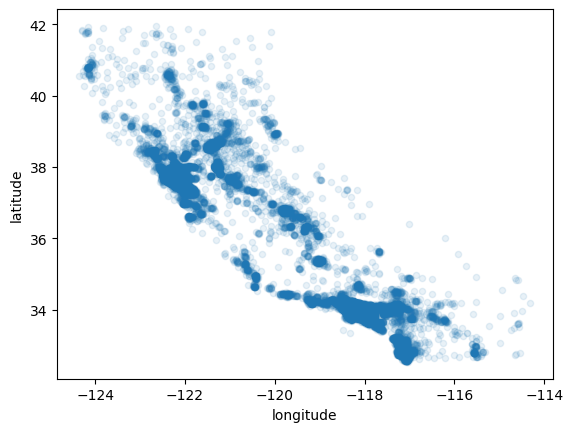

In [27]:
# visualize the geographical distribution of the dataset
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

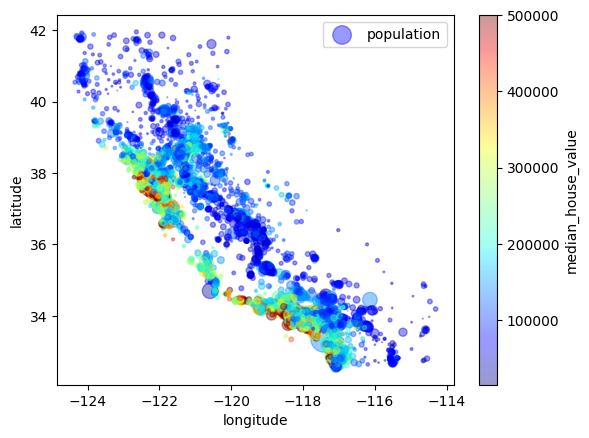

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population",
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
 )
plt.legend()

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

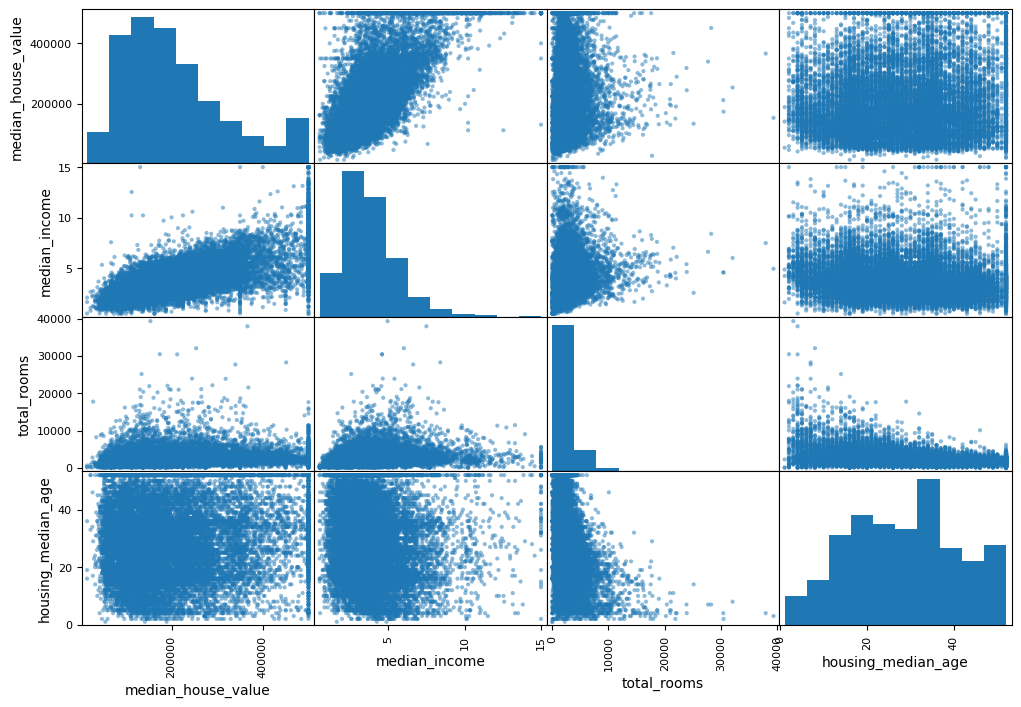

In [30]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

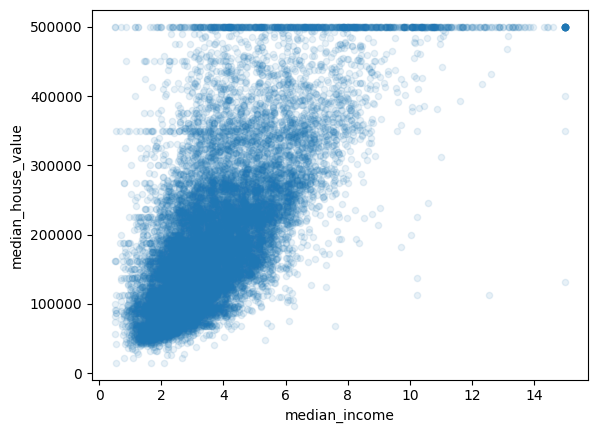

In [31]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
 alpha=0.1)

In [32]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [34]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


In [35]:
housing_data.isnull().sum()  # Check for missing values

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
income_cat              0
dtype: int64

In [36]:
housing.isnull().sum()  # Check for missing values in the training set

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [37]:
# use sklearn to handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
# Since the median is only applicable to numerical attributes, we need to create a copy of the dataset without the categorical attribute
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)


SimpleImputer(strategy='median')

This handles the missing values for every numerical variables even after our system go live.

In [38]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [39]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [40]:
# use the imputer to transform the dataset
X = imputer.transform(housing_num)